In [1]:
import sys
sys.path.append("../")

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
import arviz as az
import mpltern
import corner
import pickle
import logging

In [3]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rc_file('../notebooks/matplotlibrc')
import mpltern

In [4]:
jax.devices()

[StreamExecutorGpuDevice(id=0, process_index=0, slice_index=0),
 StreamExecutorGpuDevice(id=1, process_index=0, slice_index=0)]

In [5]:
DATA_DIR = '../data/posteriors/compare_samplers'

In [6]:
from models.np_model import NPModel

In [7]:
expand_keys = {
    'theta_bulge_poiss' : ['theta_mcdermott2022', 'theta_mcdermott2022_bbp', 'theta_mcdermott2022_x',
                           'theta_macias2019', 'theta_coleman2019'],
    'theta_ics'    : ['theta_MO_ics', 'theta_MA_ics', 'theta_MF_ics'],
    'theta_pibrem' : ['theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib'],
}

def expand_samples(samples, expand_keys):
    
    samples_keys = list(samples.keys())
    for k in samples_keys: # change dict in iteration
        if len(samples[k].shape) == 1:
            continue
        if k in expand_keys.keys():
            for i in range(samples[k].shape[1]):
                samples[expand_keys[k][i]] = samples[k][:,i]
            samples.pop(k)
        else:
            samples.pop(k)
            logging.warning(f'discarding {k}')

## 1. Poisson

In [8]:
pmodel = NPModel(
    r_outer=25,
    l_max=1,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
    non_poissonian=False
)

### 1.1 SVI

In [8]:
svi_results = pmodel.fit_svi(rng_key=jax.random.PRNGKey(4234),
                             n_steps=7500,
                             guide="iaf_mixture",
                             lr=1e-4)

100%|████████████████| 7500/7500 [00:46<00:00, 160.61it/s, init loss: 47514.6138, avg. loss [7126-7500]: 20214.3400]


In [19]:
posterior = pmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342),
                                         num_samples=50000)

In [20]:
pickle.dump(posterior, open(f'{DATA_DIR}/svi_samples.p', 'wb'))

### 1.2 NUTS

In [ ]:
pmodel.run_nuts(num_samples=10000)

In [ ]:
pickle.dump(pmodel.mcmc.get_samples(), open(f'{DATA_DIR}/nuts_samples.p', 'wb'))

### 1.3 Parallel tempering

In [9]:
pmodel.run_parallel_tempering_hmc(num_samples=10000)

sample: 100%|█████████████████████████████████████████████████████████████████| 10600/10600 [03:50<00:00, 45.98it/s]


In [ ]:
pickle.dump(pmodel.mcmc.get_samples(), open(f'{DATA_DIR}/pthmc_samples.p', 'wb'))

### 1.4 JAXNS

In [9]:
from numpyro.contrib.nested_sampling import NestedSampler

In [12]:
import logging
logger = logging.getLogger('jaxns')
logger.setLevel(logging.INFO)

In [10]:
ns = NestedSampler(pmodel.model)

In [ ]:
ns.run(jax.random.PRNGKey(42), pmodel.data)

INFO[2023-03-28 23:18:03,833]: ENS.__call__: self.approximate_sampler


In [ ]:
ns.print_summary()

## Compare

In [18]:
svi_samples = pickle.load(open(f'{DATA_DIR}/svi_samples.p', 'rb'))
expand_samples(svi_samples, expand_keys)

In [15]:
nuts_samples = pickle.load(open(f'{DATA_DIR}/nuts_samples.p', 'rb'))
expand_samples(nuts_samples, expand_keys)

In [16]:
pthmc_samples = pickle.load(open(f'{DATA_DIR}/pthmc_samples.p', 'rb'))
expand_samples(pthmc_samples, expand_keys)

In [ ]:
az.summary(nuts_samples)

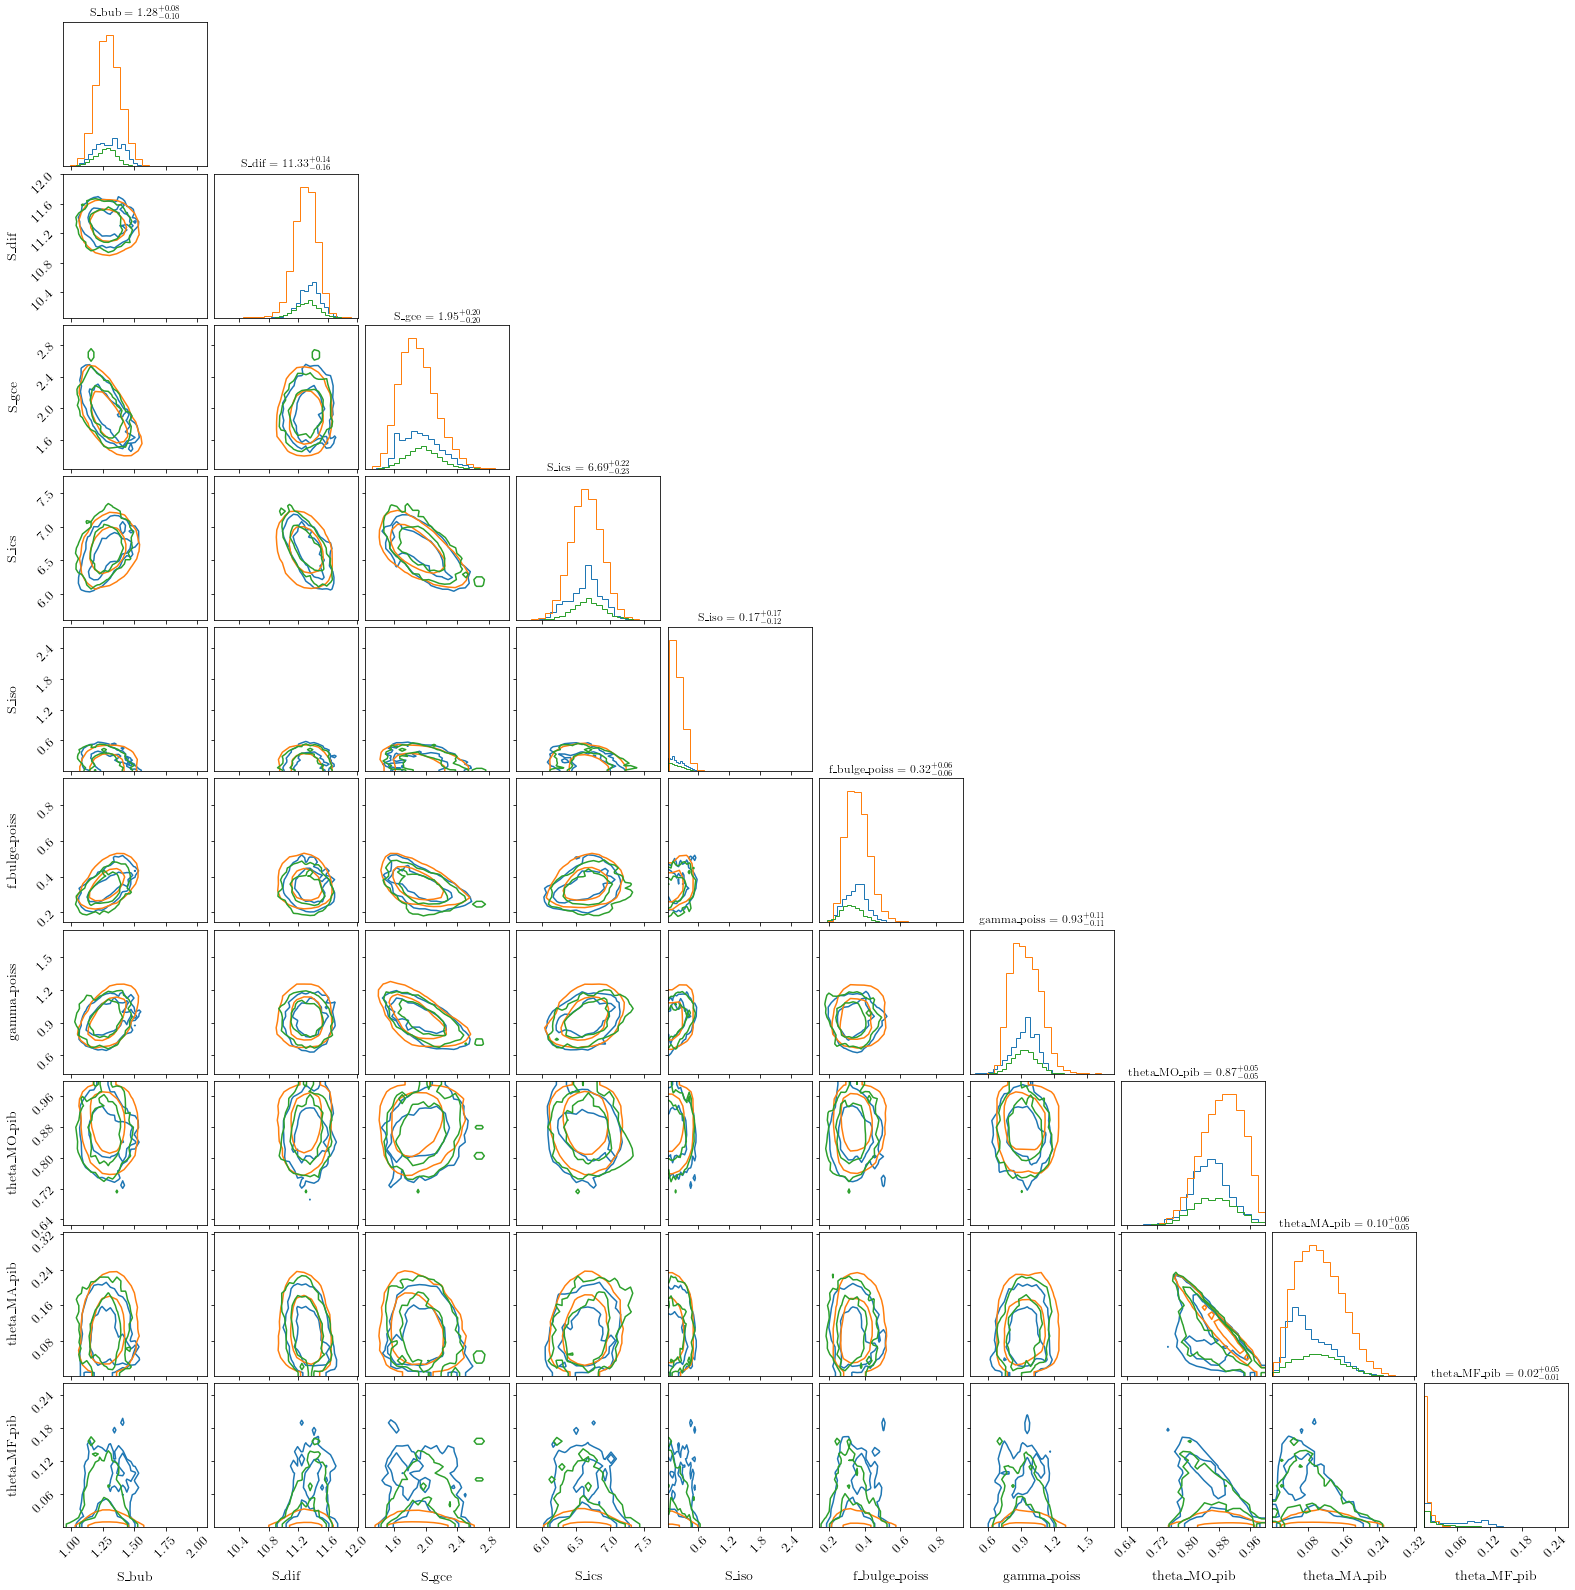

In [19]:
figure = corner.corner(
    az.from_dict(nuts_samples),
    var_names=['S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso',
          'f_bulge_poiss', 'gamma_poiss',
          'theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib'],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    levels = [0.68, 0.95],
    color = 'C0',
    plot_contours=True,
    fill_contours=False,
    plot_density=False,
    plot_datapoints=False,
)

figure = corner.corner(
    az.from_dict(svi_samples),
    var_names=['S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso',
          'f_bulge_poiss', 'gamma_poiss',
          'theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib'],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    levels = [0.68, 0.95],
    color = 'C1',
    plot_contours=True,
    fill_contours=False,
    plot_density=False,
    plot_datapoints=False,
    fig=figure
)

figure = corner.corner(
    az.from_dict(pthmc_samples),
    var_names=['S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso',
          'f_bulge_poiss', 'gamma_poiss',
          'theta_MO_pib', 'theta_MA_pib', 'theta_MF_pib'],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    levels = [0.68, 0.95],
    color = 'C2',
    plot_contours=True,
    fill_contours=False,
    plot_density=False,
    plot_datapoints=False,
    fig=figure
)